# bwin 線上賭場玩家行為分析
資料來源：bwin × 哈佛醫學院，2005–2007 年真實線上賭場行為數據

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from dotenv import load_dotenv
from pathlib import Path

load_dotenv(Path('..') / '.env')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

In [2]:
# MongoDB 連線
client = MongoClient(os.getenv('MONGO_URI'))
db = client[os.getenv('MONGO_DB')]

daily   = pd.DataFrame(list(db['daily_bets'].find({}, {'_id': 0})))
demo    = pd.DataFrame(list(db['demographics'].find({}, {'_id': 0})))
metrics = pd.DataFrame(list(db['user_metrics'].find({}, {'_id': 0})))

daily['Date'] = pd.to_datetime(daily['Date'])

print(f'daily_bets  : {len(daily):,} 筆')
print(f'demographics: {len(demo):,} 筆')
print(f'user_metrics: {len(metrics):,} 筆')

daily_bets  : 102,165 筆
demographics: 4,222 筆
user_metrics: 4,222 筆


## 1. EDA — 基本統計

In [3]:
print('=== 用戶人口分佈 ===')
print('性別分佈')
print(demo['Gender'].map({0: 'Female', 1: 'Male'}).value_counts())
print('\n前 10 國籍')
print(demo['Country'].value_counts().head(10))

=== 用戶人口分佈 ===
性別分佈
Gender
Male      3924
Female     298
Name: count, dtype: int64

前 10 國籍
Country
Germany        784
Greece         482
Austria        468
Spain          425
France         373
Denmark        355
Italy          318
Turkey         317
Poland         223
Switzerland    186
Name: count, dtype: int64


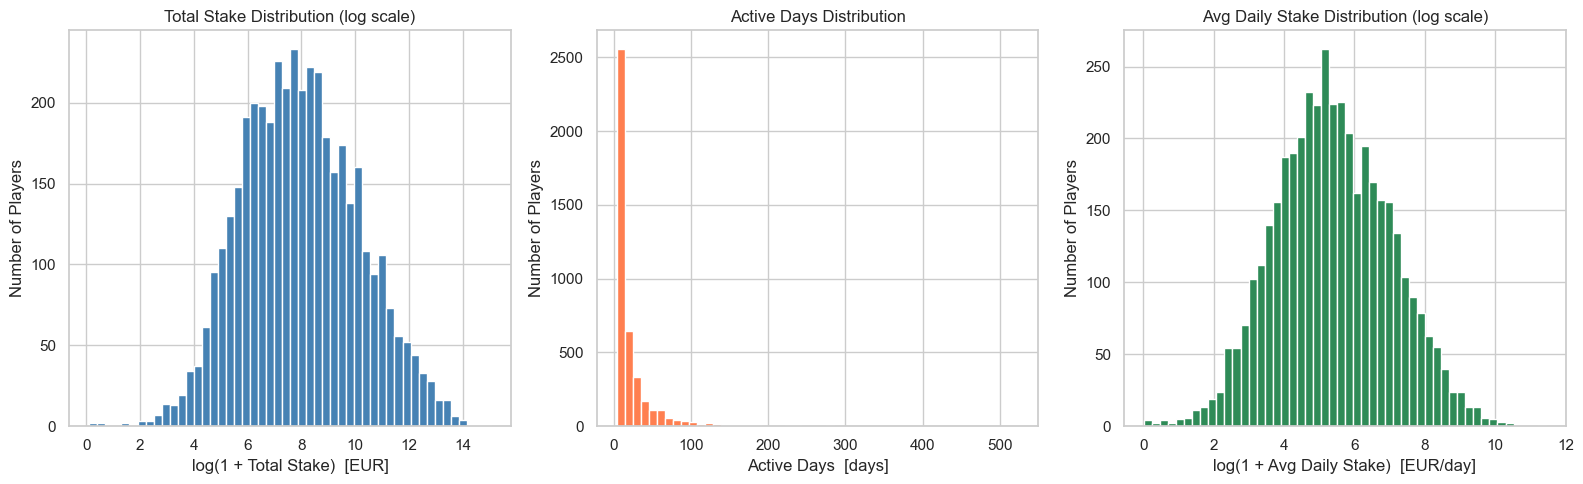

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 投注規模分佈（log scale）
axes[0].hist(np.log1p(metrics['total_stake']), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Total Stake Distribution (log scale)')
axes[0].set_xlabel('log(1 + Total Stake)  [EUR]')
axes[0].set_ylabel('Number of Players')

# 活躍天數分佈
axes[1].hist(metrics['active_days'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Active Days Distribution')
axes[1].set_xlabel('Active Days  [days]')
axes[1].set_ylabel('Number of Players')

# 每日平均投注額（log scale）
axes[2].hist(np.log1p(metrics['avg_daily_stake']), bins=50, color='seagreen', edgecolor='white')
axes[2].set_title('Avg Daily Stake Distribution (log scale)')
axes[2].set_xlabel('log(1 + Avg Daily Stake)  [EUR/day]')
axes[2].set_ylabel('Number of Players')

plt.tight_layout()
plt.show()

## 2. 職業套利客識別 — net_loss 排名與地理分佈

In [5]:
# net_loss < 0 代表玩家長期贏錢（賭場虧損）
arb = metrics[metrics['net_loss'] < 0].sort_values('net_loss')
print(f'長期獲利帳號：{len(arb)} 位（佔 {len(arb)/len(metrics)*100:.1f}%）')
print(arb[['UserID', 'net_loss', 'total_stake', 'active_days']].head(10).to_string(index=False))

長期獲利帳號：458 位（佔 10.8%）
 UserID    net_loss  total_stake  active_days
1381787 -16306.2021  155529.5479           57
1394613 -15269.7000  620784.7300          128
1330168 -11698.5000  265351.5000           31
1334560 -10742.1200  232867.4300          354
1345795  -8289.5000  205493.5000           99
1360106  -4531.5000  269490.5000           20
1364408  -3753.5996  264407.2388          182
1347041  -3219.0000  133679.0000          129
1350453  -3057.3300  181359.5800           10
1391009  -2842.0000   67836.5000           22


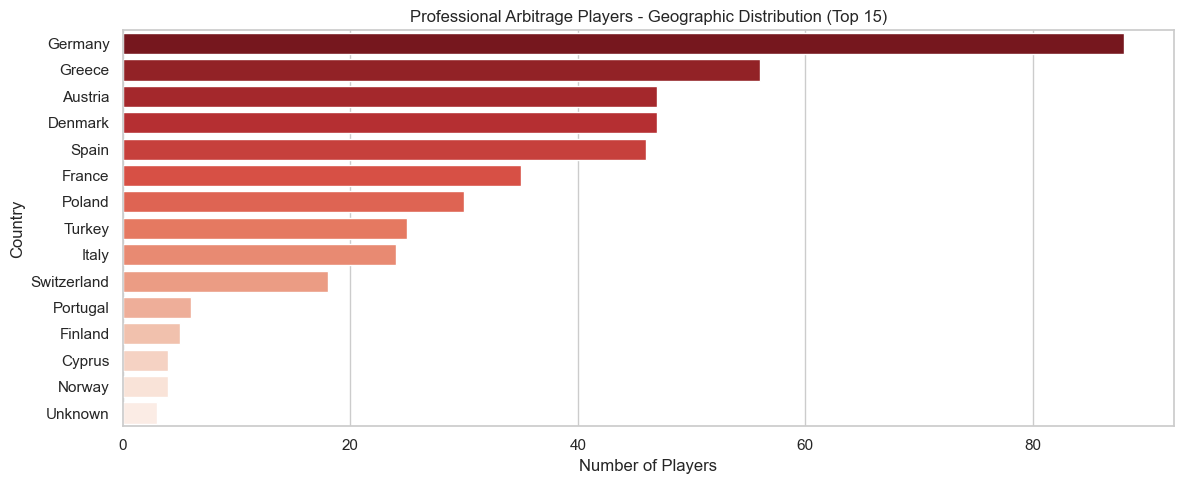

In [6]:
# 套利客地理分佈（Top 15 國家）
arb_with_country = arb.merge(demo[['UserID', 'Country']], on='UserID', how='left')
country_counts = arb_with_country['Country'].value_counts().head(15)

plt.figure(figsize=(12, 5))
sns.barplot(x=country_counts.values, y=country_counts.index, hue=country_counts.index, palette='Reds_r', legend=False)
plt.title('Professional Arbitrage Players - Geographic Distribution (Top 15)')
plt.xlabel('Number of Players')
plt.tight_layout()
plt.show()

## 3. 凹單行為分析 — 連輸後 Stake 變化

In [7]:
# 計算每位用戶每日是否虧損（GGR > 0 代表玩家當日虧損）
daily_sorted = daily.sort_values(['UserID', 'Date'])
daily_sorted['is_loss_day'] = daily_sorted['daily_GGR'] > 0

# 計算連續虧損天數
daily_sorted['loss_streak'] = (
    daily_sorted.groupby('UserID')['is_loss_day']
    .transform(lambda x: x * (x.groupby((x != x.shift()).cumsum()).cumcount() + 1))
)

# 連輸 N 天後，下一日的 Stake 變化
daily_sorted['next_stake'] = daily_sorted.groupby('UserID')['Stake'].shift(-1)
daily_sorted['stake_change'] = daily_sorted['next_stake'] - daily_sorted['Stake']

streak_analysis = (
    daily_sorted[daily_sorted['loss_streak'].isin([1, 2, 3, 4, 5])]
    .groupby('loss_streak')['stake_change']
    .mean()
    .reset_index()
)
# 英文欄位名稱供圖表使用
streak_analysis.columns = ['Consecutive Loss Days', 'Avg Stake Change (Next Day)']
print(streak_analysis.to_string(index=False))

 Consecutive Loss Days  Avg Stake Change (Next Day)
                     1                  -408.815452
                     2                    11.885358
                     3                    -0.468201
                     4                    65.781789
                     5                   161.261993


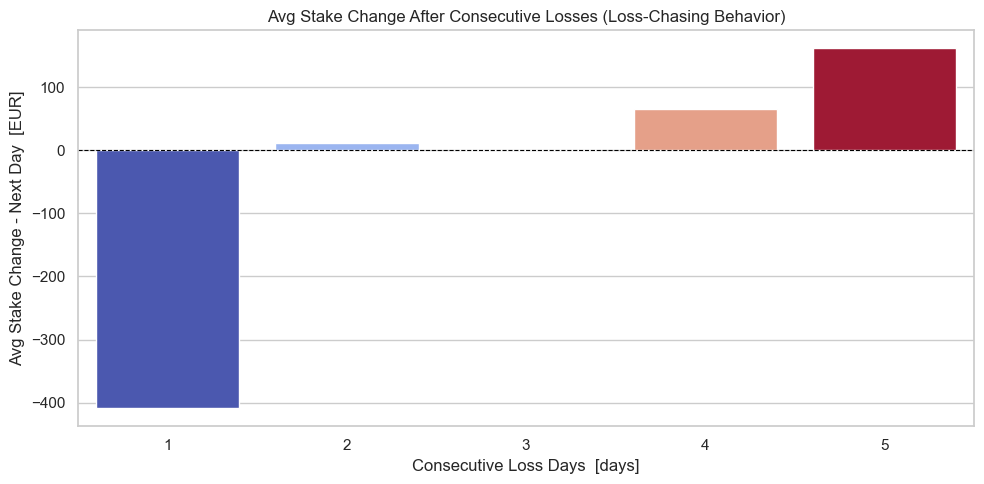

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=streak_analysis,
    x='Consecutive Loss Days', y='Avg Stake Change (Next Day)',
    hue='Consecutive Loss Days',
    palette='coolwarm',
    legend=False
)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Avg Stake Change After Consecutive Losses (Loss-Chasing Behavior)')
plt.xlabel('Consecutive Loss Days  [days]')
plt.ylabel('Avg Stake Change - Next Day  [EUR]')
plt.tight_layout()
plt.show()

## 4. 玩家生命週期分析 — 活躍壽命與流失輪廓

In [9]:
metrics['first_active'] = pd.to_datetime(metrics['first_active'])
metrics['last_active']  = pd.to_datetime(metrics['last_active'])
metrics['lifespan_days'] = (metrics['last_active'] - metrics['first_active']).dt.days

# 依活躍壽命分層
bins   = [0, 30, 90, 180, 365, 9999]
labels = ['<=30d', '31-90d', '91-180d', '181-365d', '>365d']
metrics['lifespan_group'] = pd.cut(metrics['lifespan_days'], bins=bins, labels=labels)

lifespan_dist = metrics['lifespan_group'].value_counts().sort_index()
print(lifespan_dist)

lifespan_group
<=30d        685
31-90d       530
91-180d      486
181-365d     882
>365d       1639
Name: count, dtype: int64


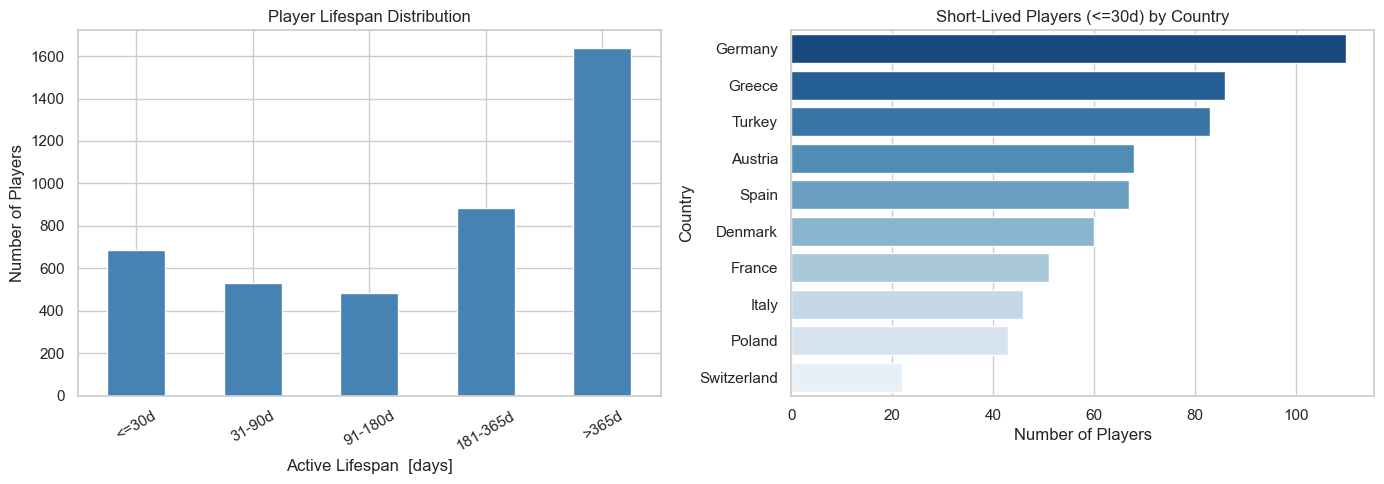

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 生命週期分佈長條圖
lifespan_dist.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Player Lifespan Distribution')
axes[0].set_xlabel('Active Lifespan  [days]')
axes[0].set_ylabel('Number of Players')
axes[0].tick_params(axis='x', rotation=30)

# 短命玩家（<=30天）國籍分佈
short_lived = metrics[metrics['lifespan_days'] <= 30]
short_with_country = short_lived.merge(demo[['UserID', 'Country']], on='UserID', how='left')
top_country = short_with_country['Country'].value_counts().head(10)
sns.barplot(x=top_country.values, y=top_country.index, hue=top_country.index, palette='Blues_r', ax=axes[1], legend=False)
axes[1].set_title('Short-Lived Players (<=30d) by Country')
axes[1].set_xlabel('Number of Players')

plt.tight_layout()
plt.show()

## 5. K-Means 玩家行為分群

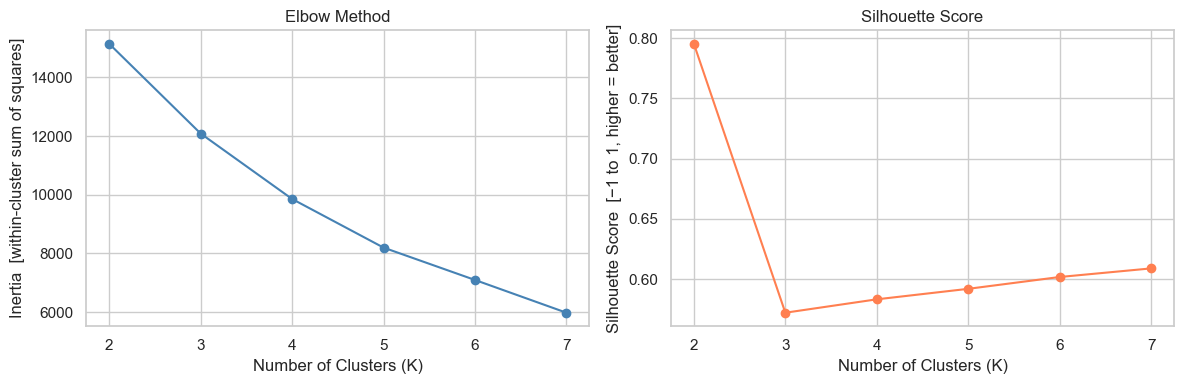

In [11]:
# 特徵向量
features = ['total_stake', 'net_loss', 'active_days', 'avg_daily_stake', 'bet_frequency']
X = metrics[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow + Silhouette 選最佳 K
inertias, sil_scores = [], []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, 'o-', color='steelblue')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia  [within-cluster sum of squares]')

axes[1].plot(list(K_range), sil_scores, 'o-', color='coral')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score  [−1 to 1, higher = better]')

plt.tight_layout()
plt.show()

In [12]:
# 選 K=4 做最終分群
K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
metrics['cluster'] = km.fit_predict(X_scaled)

# 各群特徵均值
cluster_summary = metrics.groupby('cluster')[features].mean().round(2)
print(cluster_summary)

         total_stake  net_loss  active_days  avg_daily_stake  bet_frequency
cluster                                                                    
0           11914.85    408.51        19.04           554.16           0.08
1          306791.43   8777.85       130.37          5472.36           0.26
2         1867448.01  53500.84       232.17          8328.75           0.38
3           12269.06    400.63        14.31           875.87           0.61


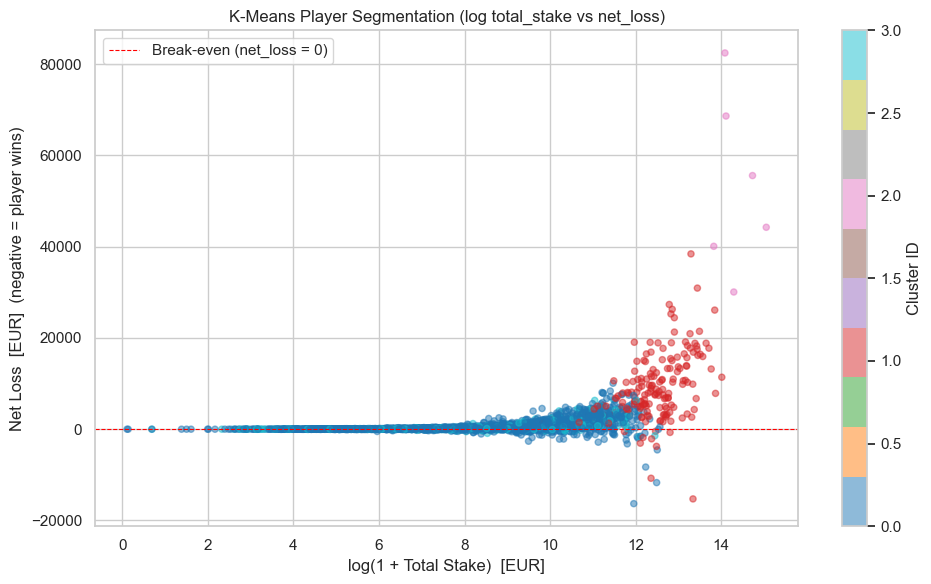


Cluster sizes:
cluster
0    3463
1     180
2       6
3     573
Name: count, dtype: int64


In [13]:
# 分群散佈圖（總投注額 vs 淨損益）
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    np.log1p(metrics['total_stake']),
    metrics['net_loss'],
    c=metrics['cluster'],
    cmap='tab10',
    alpha=0.5,
    s=20
)
plt.colorbar(scatter, label='Cluster ID')
plt.axhline(0, color='red', linewidth=0.8, linestyle='--', label='Break-even (net_loss = 0)')
plt.title('K-Means Player Segmentation (log total_stake vs net_loss)')
plt.xlabel('log(1 + Total Stake)  [EUR]')
plt.ylabel('Net Loss  [EUR]  (negative = player wins)')
plt.legend()
plt.tight_layout()
plt.show()

print('\nCluster sizes:')
print(metrics['cluster'].value_counts().sort_index())

In [14]:
# 將分群標籤回寫至 MongoDB user_metrics
from pymongo import UpdateOne

updates = [
    UpdateOne({'UserID': int(row.UserID)}, {'$set': {'cluster': int(row.cluster)}})
    for row in metrics[['UserID', 'cluster']].itertuples()
]
db['user_metrics'].bulk_write(updates)
print('分群標籤已回寫至 MongoDB user_metrics')

分群標籤已回寫至 MongoDB user_metrics
